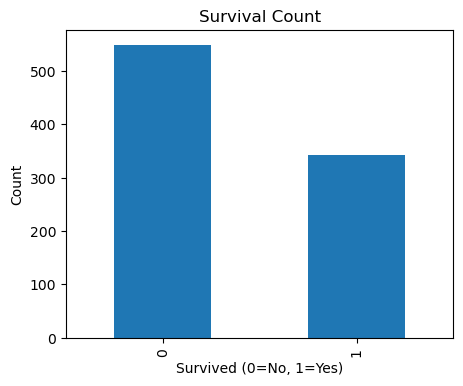

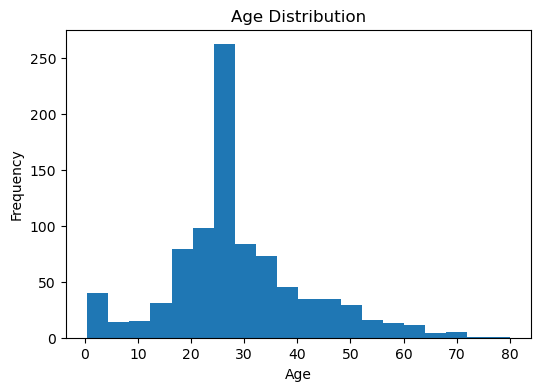

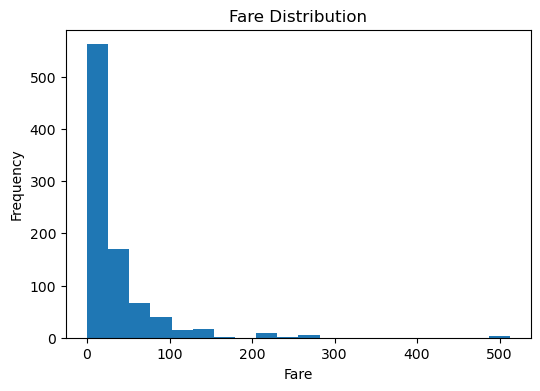

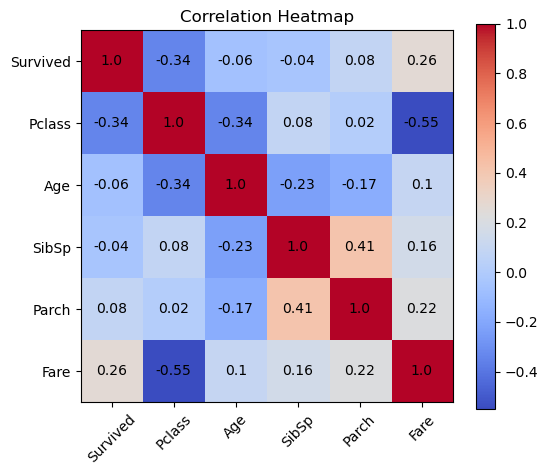

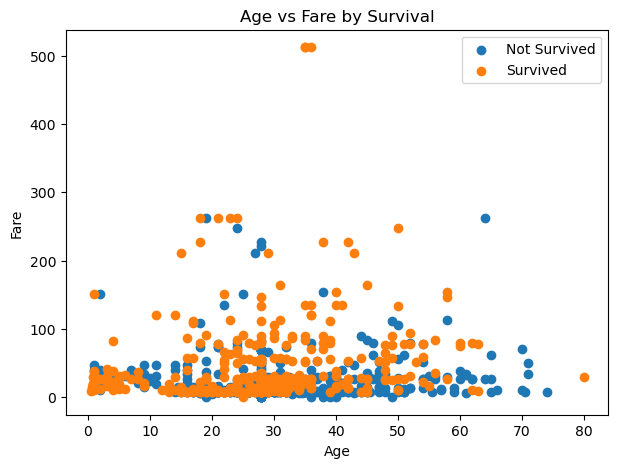

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load JSON file
df = pd.read_json("titanic.json")

# Fill missing Age values
df["Age"] = df["Age"].fillna(df["Age"].median())

# 1. Survival Chart
plt.figure(figsize=(5,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

# 2. Age Histogram
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# 3. Fare Distribution
plt.figure(figsize=(6,4))
plt.hist(df["Fare"], bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

# 4. Correlation Heatmap
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha="center", va="center")

plt.show()

# 5. Scatter Plot (Age vs Fare by Survival)
plt.figure(figsize=(7,5))

survived = df[df["Survived"] == 1]
not_survived = df[df["Survived"] == 0]

plt.scatter(not_survived["Age"],
            not_survived["Fare"],
            label="Not Survived")

plt.scatter(survived["Age"],
            survived["Fare"],
            label="Survived")

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend()
plt.show()


***Mean***


In [3]:
marks=[45,50,55,60,90]
mean=sum(marks)/len(marks)
print("Mean:",mean)

Mean: 60.0


***Median***

In [4]:
import statistics
marks=[45,50,55,60,90]
median=statistics.median(marks)
print("Median:",median)


Median: 55


***Mode***

In [19]:
import statistics
data=[10,20,20,30,40]
mode=statistics.mode(data)
print("Mode :",mode)

Mode : 20


In [7]:
#Mean,Median,Mode by usiing Data frame
import pandas as pd
df=pd.DataFrame({
    'Marks':[45,50,55,60,90]
})
print("Mean:")
print(df['Marks'].mean)
print("\nMedian:")
print(df['Marks'].median())
print("\nMode:")
print(df['Marks'].mode())


Mean:
<bound method Series.mean of 0    45
1    50
2    55
3    60
4    90
Name: Marks, dtype: int64>

Median:
55.0

Mode:
0    45
1    50
2    55
3    60
4    90
Name: Marks, dtype: int64


***Variance and standard deviation***



In [10]:
import numpy as np
data=[10,12,14,16,18]
print(np.mean(data))
variance=np.var(data)
#variance
print("variance:",variance)
#standard deviation
std=np.std(data)
print("standard deviation:",std)

14.0
variance: 8.0
standard deviation: 2.8284271247461903


### Quartile
### Formula
   

     IQR=Q3-Q1

In [11]:
#IQR code
import numpy as np
data=[5,10,15,20,25,30,35,40]
Q1=np.percentile(data,25)
Q3=np.percentile(data,75)
IQR=Q3-Q1
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)


Q1: 13.75
Q3: 31.25
IQR: 17.5


***Outlier index***

In [ ]:
Q1=np.percentile(data,25)
Q3=np.percentile(data,75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3-Q1
print(lower)
print(upper)
outliers=[x for x in data if x < lower or x > upper]
print("outliers:",outliers)

***Probability Basics***

--> Probabilit is the measure of how likely an event is to occur
--> 0 = Impossible event
--> 1 = Certain event
1.Sample Space(S)
2.Event(A)
3.Probablity of an event P(A)
4.Conditional Probablity P(A|B)
5.Bay's Theorem
Ex.Disease Testing

In [15]:
# Sample Space
sample_space={1,2,3,4,5,6}
event_A={2,4,6} #even Numbers
print("Sample Space(S):",sample_space)
print("Event A:",event_A)
# 2. Probablity P(A)
P_A=len(event_A)/len(sample_space)
print("\nProbablity of Event A")
print("P(A)=",P_A)
# 3.Conditional Probablity P(A|B)
event_B={4,5,6} #Numbers greater than 3
intersection=event_A.intersection(event_B)
P_A_given_B=len(intersection)/len(event_B)
print("\nEvent B:",event_B)
print("A intersection B:",intersection)
print("P(A|B)=",P_A_given_B)
# 4. Bayes' Theorem
'''# Example: Disease prevalence= 1%
Test sensitivity = 99%
Positive test propability= 5% '''
P_Disease= 0.01
P_Positive_given_Disease=0.99
P_Positive=0.05
p_Disease_given_Positive=(P_Positive_given_Disease*P_Disease)/P_Positive
print("\nBayes' Theorem Example")
print("P(Disease)=",P_Disease)
print("P(Positive|Disease)=",P_Positive_given_Disease)
print("P(Positive)=",P_Positive)
print("P(Disease|Positive)=",round(P_Positive_given_Disease,4))
print("Percentage=",round(P_Positive_given_Disease*100,2),"%")



Sample Space(S): {1, 2, 3, 4, 5, 6}
Event A: {2, 4, 6}

Probablity of Event A
P(A)= 0.5

Event B: {4, 5, 6}
A intersection B: {4, 6}
P(A|B)= 0.6666666666666666

Bayes' Theorem Example
P(Disease)= 0.01
P(Positive|Disease)= 0.99
P(Positive)= 0.05
P(Disease|Positive)= 0.99
Percentage= 99.0 %


***Pearson Correlation***

In [17]:
import pandas as pd
df=pd.DataFrame({
    "Hours":[1,2,3,4,5],"Marks":[20,40,50,70,90]})
corr=df["Hours"].corr(df["Marks"])
print("Person Correlation:",corr)

Person Correlation: 0.9948497511671097


***Spearman Correlation***

In [18]:
import pandas as pd
df=pd.DataFrame({"Rank_Study":[1,2,3,4,5],"Rank_Marks":[2,1,3,5,4]})
coor=df["Rank_Study"].corr(df["Rank_Marks"],method='spearman')
print("Spearman Correlation:",corr)

Spearman Correlation: 0.9948497511671097


***Correlation Matrix***

In [20]:
import pandas as pd
df=pd.DataFrame({
    "Hours":[1,2,3,4,5],
    "Marks":[2,40,50,70,90],
    "Sleep":[8,7,6,5,4]
})
print(df.corr())

         Hours    Marks    Sleep
Hours  1.00000  0.98171 -1.00000
Marks  0.98171  1.00000 -0.98171
Sleep -1.00000 -0.98171  1.00000


***Interpretation***

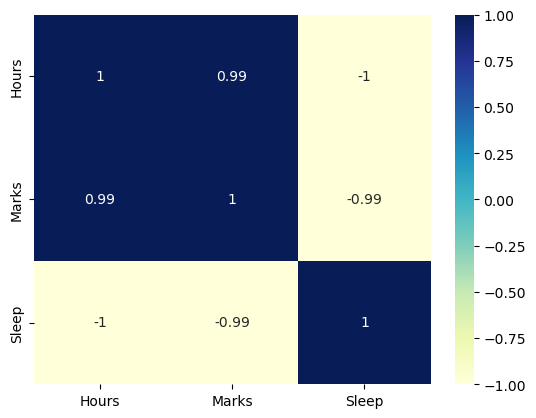

In [32]:
#Heatmap correlation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.DataFrame({
    "Hours":[1,2,3,4,5],
    "Marks":[20,40,50,70,90],
    "Sleep":[8,7,6,5,4]
})
sns.heatmap(df.corr(),annot=True,cmap='YlGnBu')
plt.show()
#Common cmap values
#coolwarm
#viridis
#YlGnBu
#Blues
#Reds
#Greens
#magma

In [ ]:
import numpy as np
scores = [60,65,70,75,80]
mean = np.mean(scores)
std = np.std(scores)
score = 80


Mean: 70.27
Standard Deviation: 9.99


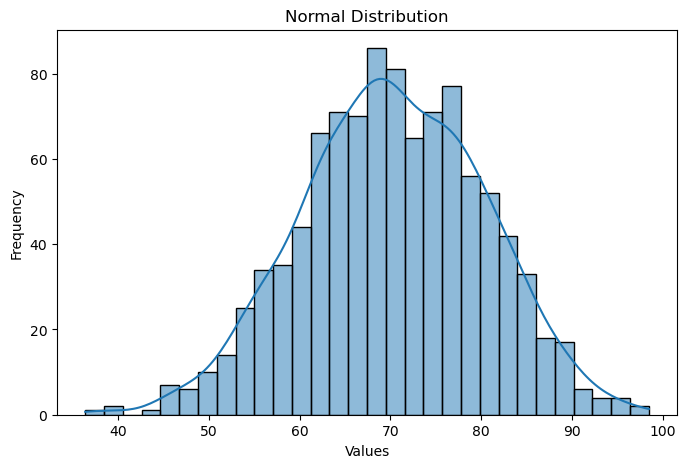

In [7]:
# Normal Distrubution
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns
# Generate normally distributed data
data = np.random.normal(loc = 70, # Mean
                        scale = 10, # Standard Deviation
                        size = 1000 # Number of values
                       )
# calculation mean and standard deviation
mean = np.mean(data)
std = np.std(data)
print("Mean:",round(mean,2))
print("Standard Deviation:",round(std,2))
#Plot Histogram
plt.figure(figsize = (8,5))
sns.histplot(data,bins = 30, kde = True)

plt.title("Normal Distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

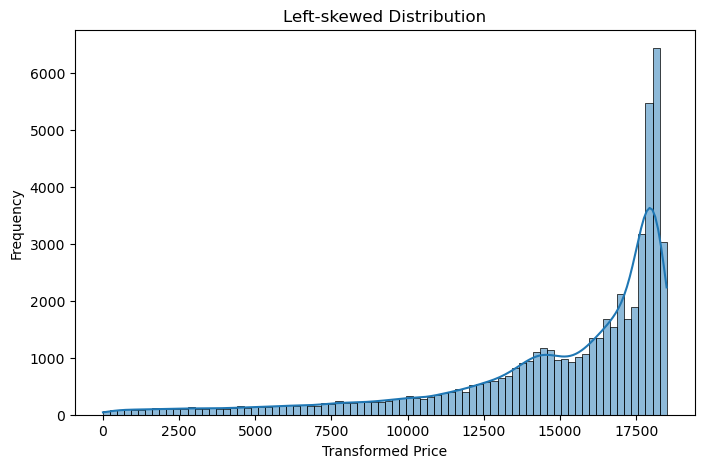

In [2]:
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
df = sns.load_dataset("diamonds")
left_skew = df["price"].max() - df["price"]
#Histogram + KDE
plt.figure(figsize = (8,5))
sns.histplot(left_skew, kde = True)
plt.title("Left-skewed Distribution")
plt.xlabel("Transformed Price")
plt.ylabel("Frequency")
plt.show()